<a href="https://colab.research.google.com/github/bahmedx/730/blob/main/Predictive_Modeling_in_Marketing_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Setup and Data Collection**
Download the Online Retail II dataset from the UCI Machine Learning Repository and load it into a pandas DataFrame. We will focus on predicting customer retention (whether a customer will purchase again in the future based on past behavior).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
)

RANDOM_STATE = 42

# Download directly from UCI
!wget -q -O online_retail_II.xlsx \
https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx

print("Loading Online Retail II dataset...")

df = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

print("Raw dataset shape:", df.shape)
display(df.head())
display(df.info())

Loading Online Retail II dataset...
Raw dataset shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


None

**Data Quality Assessment**

In [2]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df[["Quantity", "Price"]].describe().round(2))

Missing values:


,Missing
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0



Duplicate rows: 6865

Numerical summary:


,Quantity,Price
count,525461.00,525461.00
mean,10.34,4.69
std,107.42,146.13
min,-9600.00,-53594.36
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.21
max,19152.00,25111.09


**Data Preprocessing and Feature Engineering**

In [3]:
df_clean = df.dropna(subset=["Customer ID"]).copy()

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

# Retain economically meaningful purchase transactions
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["TotalSpend"] = (
    df_clean["Quantity"] * df_clean["Price"]
)

print("Clean dataset shape:", df_clean.shape)
print("Customers:", df_clean["Customer ID"].nunique())
print("Date range:",
      df_clean["InvoiceDate"].min(),
      "to",
      df_clean["InvoiceDate"].max())

Clean dataset shape: (407664, 9)
Customers: 4312
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


**Temporal feature and outcome windows**

In [4]:
max_date = df_clean["InvoiceDate"].max()
split_date = max_date - pd.DateOffset(months=3)

observation = df_clean[
    df_clean["InvoiceDate"] < split_date
].copy()

outcome = df_clean[
    df_clean["InvoiceDate"] >= split_date
].copy()

print("Prediction cutoff:", split_date)
print("Observation transactions:", len(observation))
print("Outcome transactions:", len(outcome))

Prediction cutoff: 2010-09-09 20:01:00
Observation transactions: 256539
Outcome transactions: 151125


**Customer feature engineering**

In [5]:
customer_features = observation.groupby("Customer ID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (split_date - x.max()).days
    ),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalSpend", "sum"),
    ItemVariety=("StockCode", "nunique"),
    TotalItems=("Quantity", "sum"),
    FirstPurchase=("InvoiceDate", "min")
)

customer_features["AvgOrderValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

customer_features["CustomerTenure"] = (
    split_date -
    customer_features["FirstPurchase"]
).dt.days

customer_features.drop(
    columns="FirstPurchase",
    inplace=True
)

retained_customers = set(outcome["Customer ID"].unique())

customer_features["Retained"] = (
    customer_features.index
    .isin(retained_customers)
    .astype(int)
)

print("Customer modeling dataset:",
      customer_features.shape)

print(
    "Retention rate:",
    f"{customer_features['Retained'].mean():.2%}"
)

display(customer_features.head())
display(customer_features.describe().round(2))

Customer modeling dataset: (3373, 8)
Retention rate: 57.69%


,Recency,Frequency,Monetary,ItemVariety,TotalItems,AvgOrderValue,CustomerTenure,Retained
Customer ID,,,,,,,,
12346.0,73,11,372.86,26,70,33.896364,269,0
12349.0,114,2,1268.52,47,474,634.260000,133,1
12355.0,111,1,488.21,22,303,488.210000,111,0
12358.0,94,2,1697.93,34,590,848.965000,275,1
12359.0,79,5,2012.03,82,877,402.406000,278,1


,Recency,Frequency,Monetary,ItemVariety,TotalItems,AvgOrderValue,CustomerTenure,Retained
count,3373.00,3373.00,3373.00,3373.00,3373.00,3373.00,3373.00,3373.00
mean,92.82,3.69,1680.55,53.27,1091.06,368.42,183.09,0.58
std,77.38,6.23,7303.65,71.90,6034.96,458.75,81.41,0.49
min,0.00,1.00,2.95,1.00,1.00,2.95,0.00,0.00
25%,27.00,1.00,272.96,15.00,130.00,171.70,121.00,0.00
50%,73.00,2.00,599.73,32.00,325.00,286.71,196.00,1.00
75%,142.00,4.00,1427.36,67.00,831.00,416.92,267.00,1.00
max,282.00,122.00,269041.67,1323.00,220600.00,10953.50,282.00,1.00


**Examine skewness and correlation**

Feature skewness:


,Skewness
Monetary,23.19
TotalItems,22.61
AvgOrderValue,10.86
Frequency,8.36
ItemVariety,6.03
Recency,0.79
CustomerTenure,-0.49


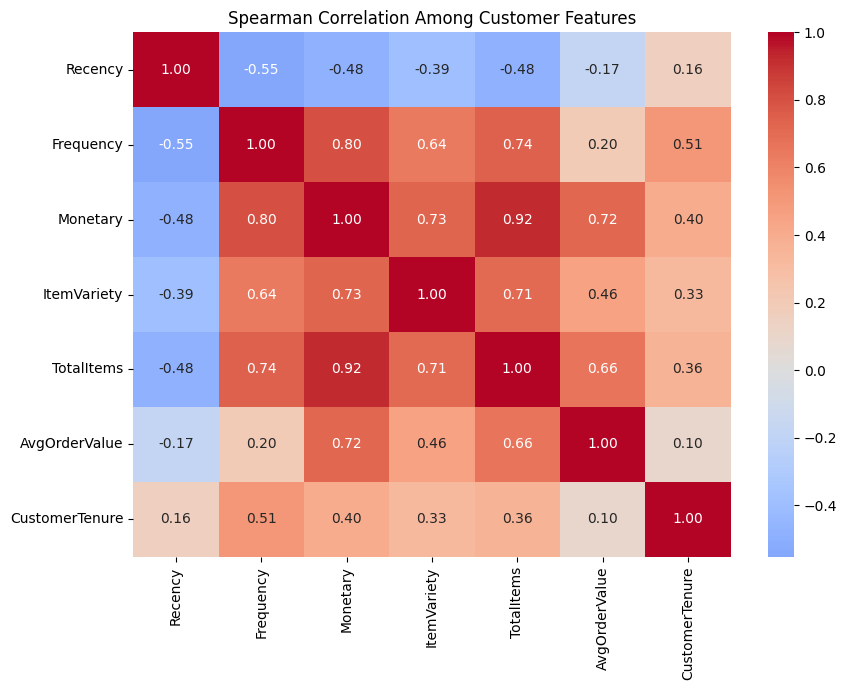

In [6]:
X = customer_features.drop(columns="Retained")
y = customer_features["Retained"]

print("Feature skewness:")
display(
    X.skew()
     .sort_values(ascending=False)
     .to_frame("Skewness")
     .round(2)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    X.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Among Customer Features")
plt.tight_layout()
plt.show()

**Train/holdout split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training customers:", len(X_train))
print("Holdout customers:", len(X_test))

print(
    "Training retention rate:",
    f"{y_train.mean():.2%}"
)

print(
    "Holdout retention rate:",
    f"{y_test.mean():.2%}"
)

Training customers: 2698
Holdout customers: 675
Training retention rate: 57.71%
Holdout retention rate: 57.63%


**Model Selection and Regularization**

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

C_grid = np.logspace(-4, 2, 30)

l1_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

l2_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "model__C": C_grid
}

l1_search = GridSearchCV(
    l1_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

l2_search = GridSearchCV(
    l2_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

l1_search.fit(X_train, y_train)
l2_search.fit(X_train, y_train)

print(
    "Optimal L1 C:",
    round(l1_search.best_params_["model__C"], 5)
)
print(
    "Best L1 CV ROC-AUC:",
    round(l1_search.best_score_, 4)
)

print(
    "Optimal L2 C:",
    round(l2_search.best_params_["model__C"], 5)
)
print(
    "Best L2 CV ROC-AUC:",
    round(l2_search.best_score_, 4)
)

Optimal L1 C: 0.0788
Best L1 CV ROC-AUC: 0.7212
Optimal L2 C: 0.03039
Best L2 CV ROC-AUC: 0.7217


**Unregularized baseline**

In [17]:
# ============================================================
# UNREGULARIZED LOGISTIC REGRESSION BASELINE
# ============================================================

baseline_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Fit baseline using training data only
baseline_pipeline.fit(X_train, y_train)

# Generate holdout predictions
baseline_pred = baseline_pipeline.predict(X_test)
baseline_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

# Calculate baseline performance
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob),
    "PR-AUC": average_precision_score(y_test, baseline_prob)
}

print("Unregularized Logistic Regression Baseline")
print("=" * 50)

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=["Not Retained", "Retained"]
    )
)

Unregularized Logistic Regression Baseline
Accuracy: 0.6785
Precision: 0.7299
Recall: 0.7018
F1: 0.7156
ROC-AUC: 0.7485
PR-AUC: 0.7970

Classification Report:
              precision    recall  f1-score   support

Not Retained       0.61      0.65      0.63       286
    Retained       0.73      0.70      0.72       389

    accuracy                           0.68       675
   macro avg       0.67      0.67      0.67       675
weighted avg       0.68      0.68      0.68       675



**Comprehensive holdout evaluation**

In [10]:
models = {
    "Unregularized": baseline_pipeline,
    "L1 (Lasso)": l1_search.best_estimator_,
    "L2 (Ridge)": l2_search.best_estimator_
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

results_df = pd.DataFrame(results).set_index("Model")

display(results_df.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Unregularized,0.6785,0.7299,0.7018,0.7156,0.7485,0.7970
L1 (Lasso),0.6919,0.7388,0.7198,0.7292,0.7519,0.7992
L2 (Ridge),0.6933,0.7370,0.7275,0.7322,0.7520,0.7997


**Classification reports**

In [11]:
for name, model in models.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            pred,
            target_names=["Not Retained", "Retained"]
        )
    )

Unregularized
              precision    recall  f1-score   support

Not Retained       0.61      0.65      0.63       286
    Retained       0.73      0.70      0.72       389

    accuracy                           0.68       675
   macro avg       0.67      0.67      0.67       675
weighted avg       0.68      0.68      0.68       675

L1 (Lasso)
              precision    recall  f1-score   support

Not Retained       0.63      0.65      0.64       286
    Retained       0.74      0.72      0.73       389

    accuracy                           0.69       675
   macro avg       0.69      0.69      0.69       675
weighted avg       0.69      0.69      0.69       675

L2 (Ridge)
              precision    recall  f1-score   support

Not Retained       0.64      0.65      0.64       286
    Retained       0.74      0.73      0.73       389

    accuracy                           0.69       675
   macro avg       0.69      0.69      0.69       675
weighted avg       0.69      0.69     

**ROC curves**

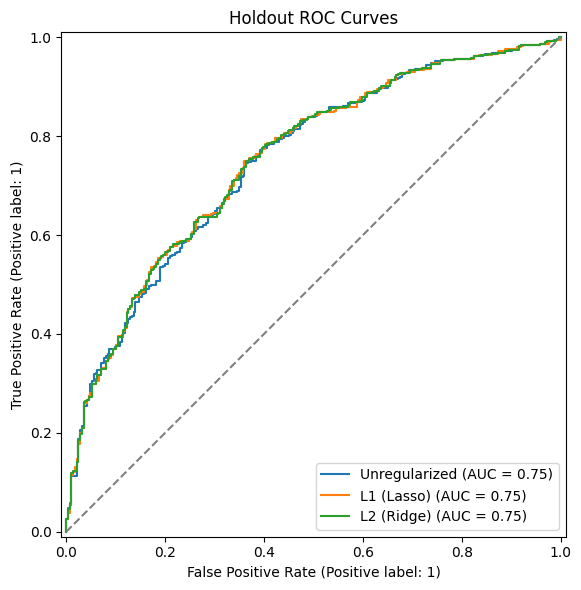

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

ax.set_title("Holdout ROC Curves")
plt.tight_layout()
plt.show()

**Precision-recall curves**

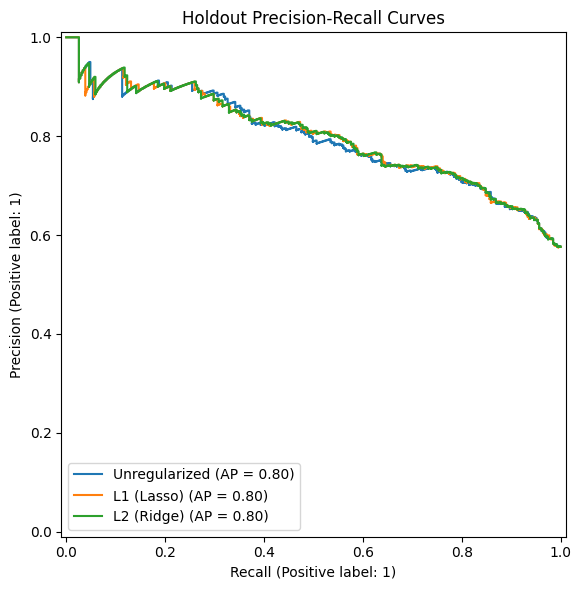

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.set_title("Holdout Precision-Recall Curves")
plt.tight_layout()
plt.show()

**Confusion matrices**

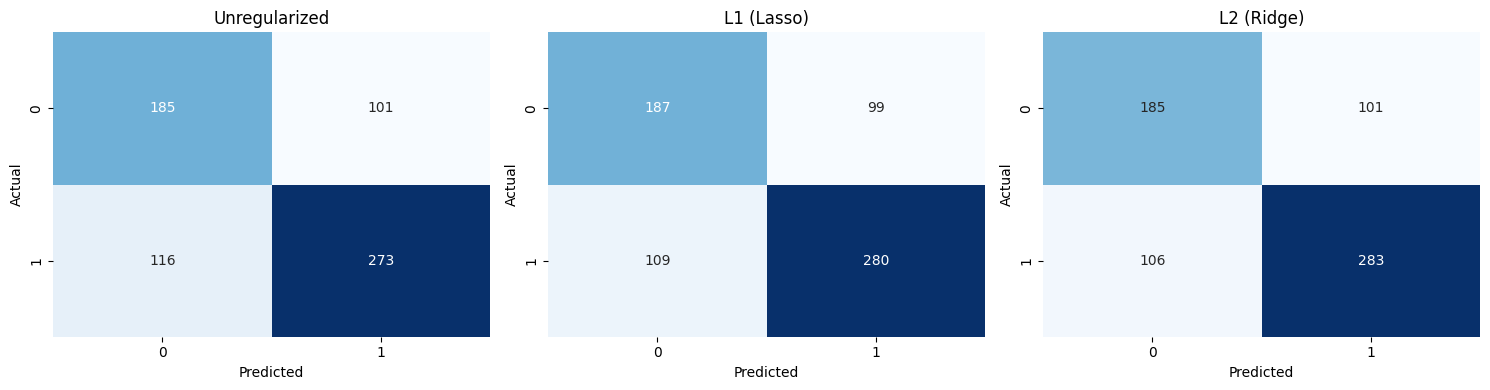

In [14]:
fig, axes = plt.subplots(
    1,
    len(models),
    figsize=(15, 4)
)

for ax, (name, model) in zip(axes, models.items()):

    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Correct coefficient extraction**

In [15]:
# Extract fitted regularized models
l1_model = l1_search.best_estimator_.named_steps["model"]
l2_model = l2_search.best_estimator_.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "L1_Coefficient": l1_model.coef_[0],
    "L2_Coefficient": l2_model.coef_[0]
})

# Identify whether L1 retained each feature
coef_df["L1_Selected"] = (
    np.abs(coef_df["L1_Coefficient"]) > 1e-8
)

# Sort features by absolute L1 coefficient magnitude
coef_df["Absolute_L1"] = coef_df["L1_Coefficient"].abs()

coef_df = (
    coef_df
    .sort_values("Absolute_L1", ascending=False)
    .reset_index(drop=True)
)

display(
    coef_df[
        [
            "Feature",
            "L1_Coefficient",
            "L2_Coefficient",
            "L1_Selected"
        ]
    ].round(4)
)

,Feature,L1_Coefficient,L2_Coefficient,L1_Selected
0,Recency,-0.5267,-0.5226,True
1,CustomerTenure,0.4035,0.4078,True
2,ItemVariety,0.3332,0.3346,True
3,Frequency,0.3128,0.2876,True
4,AvgOrderValue,-0.0144,-0.0331,True
5,TotalItems,-0.0040,-0.0060,True
6,Monetary,0.0000,0.0291,False


**Coefficient visualization**

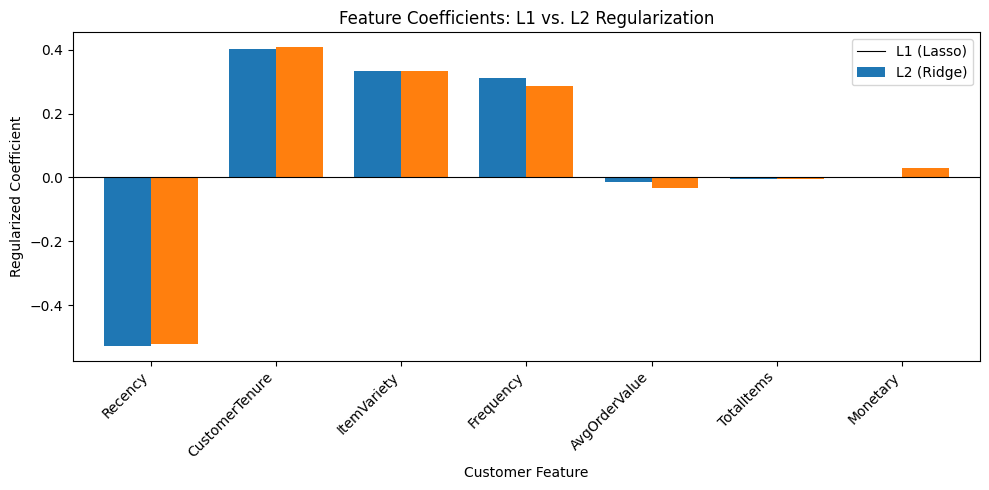

In [18]:
# ============================================================
# COEFFICIENT VISUALIZATION
# ============================================================

plot_df = (
    coef_df[
        ["Feature", "L1_Coefficient", "L2_Coefficient"]
    ]
    .set_index("Feature")
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.75
)

plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.ylabel("Regularized Coefficient")
plt.xlabel("Customer Feature")
plt.title(
    "Feature Coefficients: L1 vs. L2 Regularization"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    ["L1 (Lasso)", "L2 (Ridge)"]
)

plt.tight_layout()
plt.show()

**Dynamic Model Interpretation**

In [22]:
# ============================================================
# DYNAMIC MODEL INTERPRETATION
# ============================================================

# ------------------------------------------------------------
# 1. Extract model performance
# ------------------------------------------------------------

best_model = results_df["ROC-AUC"].idxmax()

best_auc = results_df.loc[best_model, "ROC-AUC"]
best_accuracy = results_df.loc[best_model, "Accuracy"]
best_precision = results_df.loc[best_model, "Precision"]
best_recall = results_df.loc[best_model, "Recall"]
best_f1 = results_df.loc[best_model, "F1"]
best_pr_auc = results_df.loc[best_model, "PR-AUC"]

baseline_auc = results_df.loc["Unregularized", "ROC-AUC"]
l1_auc = results_df.loc["L1 (Lasso)", "ROC-AUC"]
l2_auc = results_df.loc["L2 (Ridge)", "ROC-AUC"]

l1_precision = results_df.loc["L1 (Lasso)", "Precision"]
l2_precision = results_df.loc["L2 (Ridge)", "Precision"]

l1_recall = results_df.loc["L1 (Lasso)", "Recall"]
l2_recall = results_df.loc["L2 (Ridge)", "Recall"]

auc_difference = abs(l1_auc - l2_auc)


# ------------------------------------------------------------
# 2. Extract cross-validation results
# ------------------------------------------------------------

l1_c = l1_search.best_params_["model__C"]
l2_c = l2_search.best_params_["model__C"]

l1_cv_auc = l1_search.best_score_
l2_cv_auc = l2_search.best_score_


# ------------------------------------------------------------
# 3. Analyze L1 feature selection
# ------------------------------------------------------------

coef_analysis = coef_df.copy()

coef_analysis["L1_Selected"] = (
    coef_analysis["L1_Coefficient"].abs() > 1e-8
)

selected_features = coef_analysis.loc[
    coef_analysis["L1_Selected"], "Feature"
].tolist()

eliminated_features = coef_analysis.loc[
    ~coef_analysis["L1_Selected"], "Feature"
].tolist()

n_selected = len(selected_features)
n_total = len(coef_analysis)


# Strongest positive and negative L1 coefficients

positive_coef = coef_analysis[
    coef_analysis["L1_Coefficient"] > 1e-8
].sort_values(
    "L1_Coefficient",
    ascending=False
)

negative_coef = coef_analysis[
    coef_analysis["L1_Coefficient"] < -1e-8
].sort_values(
    "L1_Coefficient"
)

strongest_positive = (
    positive_coef.iloc[0]
    if not positive_coef.empty
    else None
)

strongest_negative = (
    negative_coef.iloc[0]
    if not negative_coef.empty
    else None
)


# ------------------------------------------------------------
# 4. Predictive performance interpretation
# ------------------------------------------------------------

performance_text = (
    f"The strongest holdout performance based on ROC-AUC was produced by "
    f"{best_model}, with ROC-AUC = {best_auc:.4f}. "
    f"The model achieved accuracy of {best_accuracy:.1%}, precision of "
    f"{best_precision:.1%}, recall of {best_recall:.1%}, "
    f"F1-score of {best_f1:.3f}, and PR-AUC of {best_pr_auc:.4f}. "
    "ROC-AUC is used as the primary comparison metric because it evaluates "
    "discrimination across classification thresholds, while precision, "
    "recall, F1-score, and PR-AUC provide complementary measures of "
    "classification performance."
)


# ------------------------------------------------------------
# 5. L1 vs. L2 interpretation
# ------------------------------------------------------------

if auc_difference < 0.001:

    comparison_text = (
        f"L1 and L2 produced virtually identical holdout discrimination. "
        f"L1 achieved ROC-AUC = {l1_auc:.4f}, compared with "
        f"{l2_auc:.4f} for L2, a difference of only "
        f"{auc_difference:.4f}. This difference is negligible in practical "
        "terms, so model choice should also consider feature parsimony and "
        "interpretability."
    )

elif l1_auc > l2_auc:

    comparison_text = (
        f"L1 achieved higher holdout ROC-AUC than L2 "
        f"({l1_auc:.4f} vs. {l2_auc:.4f}). "
        "This suggests that L1 preserved predictive discrimination while "
        "also providing the potential benefit of sparse feature selection."
    )

else:

    comparison_text = (
        f"L2 achieved higher holdout ROC-AUC than L1 "
        f"({l2_auc:.4f} vs. {l1_auc:.4f}). "
        "This suggests that retaining predictors while shrinking their "
        "coefficients produced stronger discrimination in this sample."
    )


# ------------------------------------------------------------
# 6. Impact of regularization
# ------------------------------------------------------------

best_regularized_auc = max(l1_auc, l2_auc)

best_regularized_model = (
    "L1 (Lasso)"
    if l1_auc >= l2_auc
    else "L2 (Ridge)"
)

auc_gain = best_regularized_auc - baseline_auc


if auc_gain > 0.001:

    regularization_text = (
        f"The best regularized model, {best_regularized_model}, improved "
        f"holdout ROC-AUC from {baseline_auc:.4f} for the unregularized "
        f"baseline to {best_regularized_auc:.4f}, an absolute increase of "
        f"{auc_gain:.4f}. The improvement is modest, but regularization "
        "also controls coefficient magnitude and model complexity."
    )

elif auc_gain >= 0:

    regularization_text = (
        f"The best regularized model produced ROC-AUC = "
        f"{best_regularized_auc:.4f}, compared with {baseline_auc:.4f} "
        "for the unregularized baseline. Predictive performance was "
        "essentially comparable, so regularization contributes primarily "
        "through coefficient control and potential model simplification."
    )

else:

    regularization_text = (
        f"The unregularized model achieved ROC-AUC = {baseline_auc:.4f}, "
        f"compared with {best_regularized_auc:.4f} for the best regularized "
        "model. Regularization did not improve discrimination in this sample, "
        "although coefficient shrinkage may still improve model stability "
        "and interpretability."
    )


# ------------------------------------------------------------
# 7. Cross-validation interpretation
# ------------------------------------------------------------

cv_text = (
    f"Five-fold stratified cross-validation selected C = {l1_c:.5f} "
    f"for L1 and C = {l2_c:.5f} for L2. Mean cross-validated ROC-AUC "
    f"was {l1_cv_auc:.4f} for L1 and {l2_cv_auc:.4f} for L2. "
    "Because C is the inverse of regularization strength, smaller C values "
    "represent stronger coefficient shrinkage."
)


# ------------------------------------------------------------
# 8. Feature selection interpretation
# ------------------------------------------------------------

if eliminated_features:

    feature_text = (
        f"L1 retained {n_selected} of {n_total} predictors and reduced "
        f"{len(eliminated_features)} coefficient(s) to zero: "
        f"{', '.join(eliminated_features)}. "
        "This demonstrates L1's embedded feature-selection capability. "
        "L2, in contrast, retains predictors while shrinking their "
        "coefficient magnitudes."
    )

else:

    feature_text = (
        f"L1 retained all {n_total} predictors at the selected "
        "regularization strength. Therefore, L1 provided coefficient "
        "shrinkage but did not eliminate features in this fitted model."
    )


# ------------------------------------------------------------
# 9. Coefficient interpretation
# ------------------------------------------------------------

coefficient_parts = []

if strongest_positive is not None:

    coefficient_parts.append(
        f"The strongest positive L1 coefficient was "
        f"{strongest_positive['Feature']} "
        f"({strongest_positive['L1_Coefficient']:.4f}), indicating a "
        "positive association with the modeled probability of retention "
        "after accounting for the other predictors."
    )

if strongest_negative is not None:

    coefficient_parts.append(
        f"The strongest negative L1 coefficient was "
        f"{strongest_negative['Feature']} "
        f"({strongest_negative['L1_Coefficient']:.4f}), indicating a "
        "negative association with the modeled probability of retention "
        "after accounting for the other predictors."
    )

coefficient_parts.append(
    "Because the predictors were transformed using RobustScaler, coefficient "
    "magnitudes should be interpreted as relative contributions on the "
    "transformed scale rather than as raw-unit or causal effects."
)

coefficient_text = " ".join(coefficient_parts)


# ------------------------------------------------------------
# 10. Precision and recall interpretation
# ------------------------------------------------------------

classification_text = (
    f"L1 achieved precision of {l1_precision:.1%} and recall of "
    f"{l1_recall:.1%}, while L2 achieved precision of "
    f"{l2_precision:.1%} and recall of {l2_recall:.1%}. "
    "Because Retained = 1 is the positive class, recall measures the "
    "proportion of customers who actually returned and were correctly "
    "identified. Customers with low predicted retention probabilities, "
    "rather than the positive class itself, represent the primary candidates "
    "for potential re-engagement."
)


# ------------------------------------------------------------
# 11. Real-world marketing interpretation
# ------------------------------------------------------------

marketing_text = (
    "Predicted retention probabilities can be used to rank customers by "
    "their estimated likelihood of returning during the future outcome "
    "period. Customers with lower predicted retention probabilities could "
    "be prioritized for re-engagement campaigns. However, the targeting "
    "threshold should reflect campaign cost, expected customer value, "
    "marketing capacity, and the consequences of incorrect targeting. "
    "Because this is a predictive observational model, the results indicate "
    "associations rather than causal effects. Incremental campaign impact "
    "should ultimately be validated through a controlled experiment or "
    "A/B test."
)


# ------------------------------------------------------------
# 12. Overall conclusion
# ------------------------------------------------------------

if best_model == "L2 (Ridge)" and auc_difference < 0.001:

    conclusion_text = (
        f"Overall, L2 produced the highest observed holdout ROC-AUC "
        f"({l2_auc:.4f}), but its advantage over L1 "
        f"({l1_auc:.4f}) was negligible. The two regularized models should "
        "therefore be considered essentially equivalent in predictive "
        "discrimination. The final model choice should balance predictive "
        "performance with the interpretability and feature-selection "
        "advantages offered by L1."
    )

elif best_model == "L1 (Lasso)":

    conclusion_text = (
        f"Overall, L1 produced the highest holdout ROC-AUC "
        f"({l1_auc:.4f}). Its combination of predictive discrimination, "
        "coefficient shrinkage, and potential feature selection provides "
        "a strong balance of performance and interpretability."
    )

else:

    conclusion_text = (
        f"Overall, {best_model} produced the highest holdout ROC-AUC "
        f"({best_auc:.4f}). Model selection should nevertheless consider "
        "the complete set of evaluation metrics, model complexity, and "
        "the intended marketing use case rather than relying on ROC-AUC alone."
    )


# ============================================================
# 13. DISPLAY COMPLETE DYNAMIC INTERPRETATION
# ============================================================

print("=" * 80)
print("MODEL INTERPRETATION AND BUSINESS IMPLICATIONS")
print("=" * 80)

print("\n1. Predictive Performance")
print(performance_text)

print("\n2. L1 vs. L2 Comparison")
print(comparison_text)

print("\n3. Impact of Regularization")
print(regularization_text)

print("\n4. Cross-Validated Regularization Strength")
print(cv_text)

print("\n5. Feature Selection and Interpretability")
print(feature_text)

print("\n6. Coefficient Interpretation")
print(coefficient_text)

print("\n7. Precision and Recall Interpretation")
print(classification_text)

print("\n8. Marketing and Real-World Implications")
print(marketing_text)

print("\n9. Overall Model Conclusion")
print(conclusion_text)

MODEL INTERPRETATION AND BUSINESS IMPLICATIONS

1. Predictive Performance
The strongest holdout performance based on ROC-AUC was produced by L2 (Ridge), with ROC-AUC = 0.7520. The model achieved accuracy of 69.3%, precision of 73.7%, recall of 72.8%, F1-score of 0.732, and PR-AUC of 0.7997. ROC-AUC is used as the primary comparison metric because it evaluates discrimination across classification thresholds, while precision, recall, F1-score, and PR-AUC provide complementary measures of classification performance.

2. L1 vs. L2 Comparison
L1 and L2 produced virtually identical holdout discrimination. L1 achieved ROC-AUC = 0.7519, compared with 0.7520 for L2, a difference of only 0.0001. This difference is negligible in practical terms, so model choice should also consider feature parsimony and interpretability.

3. Impact of Regularization
The best regularized model, L2 (Ridge), improved holdout ROC-AUC from 0.7485 for the unregularized baseline to 0.7520, an absolute increase of 0.0035

In [24]:
# ============================================================
# FINAL MODEL SUMMARY
# ============================================================

print("=" * 72)
print("FINAL MODEL SUMMARY")
print("=" * 72)

# Display models from highest to lowest holdout ROC-AUC
display(
    results_df
    .sort_values("ROC-AUC", ascending=False)
    .round(4)
)

# Identify best holdout model
best_model_name = results_df["ROC-AUC"].idxmax()
best_auc = results_df.loc[best_model_name, "ROC-AUC"]

# Identify L1-selected and eliminated features directly
l1_selected_mask = (
    coef_df["L1_Coefficient"].abs() > 1e-8
)

selected_features = coef_df.loc[
    l1_selected_mask,
    "Feature"
].tolist()

eliminated_features = coef_df.loc[
    ~l1_selected_mask,
    "Feature"
].tolist()

n_selected = len(selected_features)
n_total = len(coef_df)

# Print summary
print(f"Best holdout model: {best_model_name}")
print(f"Best ROC-AUC: {best_auc:.4f}")

print(
    f"\nL1 selected {n_selected} of "
    f"{n_total} customer features."
)

if eliminated_features:
    print(
        "L1 eliminated: "
        + ", ".join(eliminated_features)
    )
else:
    print(
        "L1 did not eliminate any features completely "
        "at the selected regularization strength."
    )

print(
    "L1 retained: "
    + ", ".join(selected_features)
)

FINAL MODEL SUMMARY


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
L2 (Ridge),0.6933,0.7370,0.7275,0.7322,0.7520,0.7997
L1 (Lasso),0.6919,0.7388,0.7198,0.7292,0.7519,0.7992
Unregularized,0.6785,0.7299,0.7018,0.7156,0.7485,0.7970


Best holdout model: L2 (Ridge)
Best ROC-AUC: 0.7520

L1 selected 6 of 7 customer features.
L1 eliminated: Monetary
L1 retained: Recency, CustomerTenure, ItemVariety, Frequency, AvgOrderValue, TotalItems


**Evaluation and Real-World Interpretation**

In [26]:
# ============================================================
# GENERATE HOLDOUT PREDICTIONS
# ============================================================

# Use the best cross-validated L1 and L2 pipelines.
# RobustScaler is already included inside each pipeline,
# so predictions must use X_test directly.

l1_best = l1_search.best_estimator_
l2_best = l2_search.best_estimator_

# L1 predictions
y_pred_l1 = l1_best.predict(X_test)
y_prob_l1 = l1_best.predict_proba(X_test)[:, 1]

# L2 predictions
y_pred_l2 = l2_best.predict(X_test)
y_prob_l2 = l2_best.predict_proba(X_test)[:, 1]

# Unregularized baseline predictions
y_pred_baseline = baseline_pipeline.predict(X_test)
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Holdout predictions generated successfully.")
print(f"L1 predictions: {len(y_pred_l1)}")
print(f"L2 predictions: {len(y_pred_l2)}")
print(f"Baseline predictions: {len(y_pred_baseline)}")

Holdout predictions generated successfully.
L1 predictions: 675
L2 predictions: 675
Baseline predictions: 675
